<a href="https://colab.research.google.com/github/robnez44/Binance-Python-Tests/blob/main/stock_screener.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from datetime import datetime, timezone
from typing import Any, Dict, List
from decimal import Decimal
import matplotlib.pyplot as plt
import csv
import json

In [ ]:
def timestamp_to_utc(timestamp_ms: int) -> datetime:
    return datetime.fromtimestamp(timestamp_ms / 1000, tz=timezone.utc)

# Convertir a diccionario
def toDicto(kline: List[Any]) -> Dict[str, Any]:
    return {
        "open_time": timestamp_to_utc(int(kline[0])),
        "open_price": Decimal(kline[1]),
        "high_price": Decimal(kline[2]),
        "low_price": Decimal(kline[3]),
        "close_price": Decimal(kline[4]),
        "volume": Decimal(kline[5]),
        "close_time": timestamp_to_utc(int(kline[6])),
        "quote_asset_volume": Decimal(kline[7]),
        "number_of_trades": int(kline[8]),
        "taker_buy_base_asset_volume": Decimal(kline[9]),
        "taker_buy_quote_asset_volume": Decimal(kline[10]),
    }

In [ ]:
csv_path = "BTCUSDT-4h-2026-02-04_a_12.csv"

data: List[List[Any]] = []
with open(csv_path, "r", newline="") as f:
    reader = csv.reader(f)
    header = next(reader, None)
    for row in reader:
        # row ya está en el mismo orden; mantenemos strings numéricas como en la API
        # aseguramos que open_time/close_time luego sean int en toDicto
        data.append([
            row[0],  # open_time (ms)
            row[1],  # open
            row[2],  # high
            row[3],  # low
            row[4],  # close
            row[5],  # volume
            row[6],  # close_time (ms)
            row[7],  # quote_asset_volume
            row[8],  # number_of_trades
            row[9],  # taker_buy_base_asset_volume
            row[10], # taker_buy_quote_asset_volume
            row[11], # ignore
        ])

In [ ]:
# Verificar la fecha de la primera vela
timestamp_ms = int(data[0][0])
date_utc = timestamp_to_utc(timestamp_ms)
print("Fecha de apertura de la primera vela:", date_utc)

Fecha de apertura de la primera vela: 2026-02-04 04:00:00+00:00


In [ ]:
# Limpiar data
cleaned_data = [toDicto(kline) for kline in data]
print(json.dumps(cleaned_data[-1], indent=3, default=str))  # última vela

{
   "open_time": "2026-02-12 00:00:00+00:00",
   "open_price": "67082.52000000",
   "high_price": "68047.48000000",
   "low_price": "67055.53000000",
   "close_price": "67580.99000000",
   "volume": "2100.97039000",
   "close_time": "2026-02-12 03:59:59.999000+00:00",
   "quote_asset_volume": "141942869.01330560",
   "number_of_trades": 770076,
   "taker_buy_base_asset_volume": "965.91966000",
   "taker_buy_quote_asset_volume": "65263272.24195290"
}


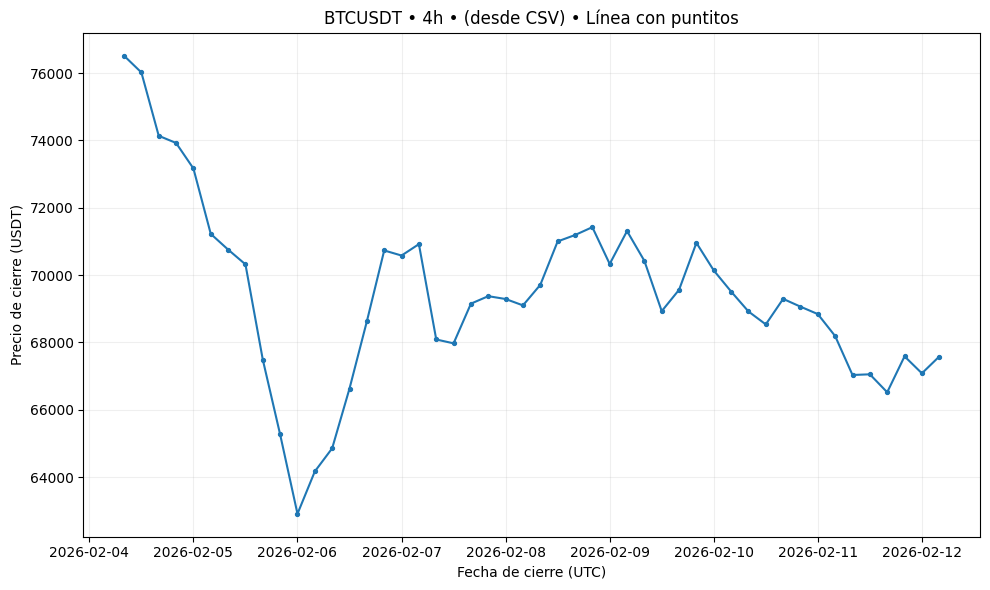

In [ ]:
# Series para el gráfico
x = [k["close_time"] for k in cleaned_data]
y = [float(k["close_price"]) for k in cleaned_data]

# Gráfico

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y, linestyle='-', color='#1f77b4', marker='o', markersize=3, markeredgecolor='#1f77b4', markeredgewidth=0.8,)
ax.set_xlabel("Fecha de cierre (UTC)")
ax.set_ylabel("Precio de cierre (USDT)")
ax.set_title("BTCUSDT • 4h • (desde CSV) • Línea con puntitos")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()



In [23]:
import pandas as pd
import mplfinance as mpf

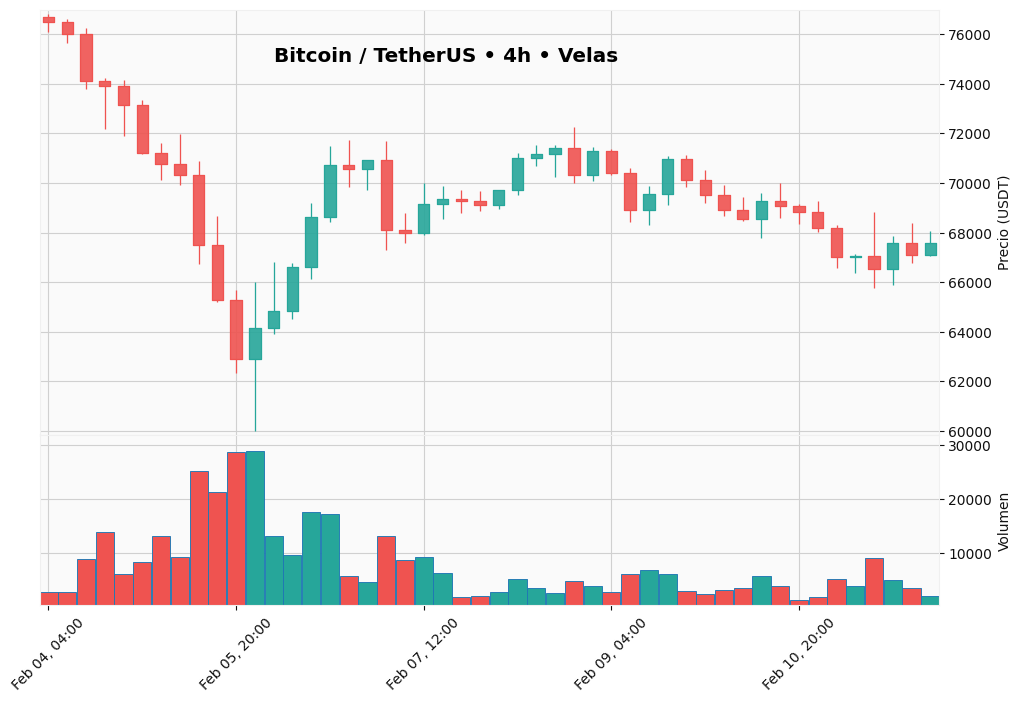

In [33]:
# Graficar con velas
# - Índice: datetime (open_time)
# - Columnas: 'Open','High','Low','Close','Volume'
df = pd.DataFrame({
    "open_time": [k["open_time"] for k in cleaned_data],
    "open":      [float(k["open_price"]) for k in cleaned_data],
    "high":      [float(k["high_price"]) for k in cleaned_data],
    "low":       [float(k["low_price"]) for k in cleaned_data],
    "close":     [float(k["close_price"]) for k in cleaned_data],
    "volume":    [float(k["volume"]) for k in cleaned_data],
})
df.set_index("open_time", inplace=True)
df.index = pd.to_datetime(df.index, utc=True)  # asegurar índice datetime (UTC)

ohlc = df.rename(columns={
    "open":"Open", "high":"High", "low":"Low", "close":"Close", "volume":"Volume"
})

# Estilo de colores
mc = mpf.make_marketcolors(
    up="red",    # color vela alcista
    down="green",  # color vela bajista
    edge="inherit",
    wick="inherit",
    volume="in"
)

# Graficar velas + volumen
mpf.plot(
    ohlc,
    type="candle",
    volume=True,
    style=style,
    title="Bitcoin / TetherUS • 4h • Velas",
    ylabel="Precio (USDT)",
    ylabel_lower="Volumen",
    figratio=(12, 8),
    figscale=1.2,
    tight_layout=True
)